<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Laboratorios/Laboratorio05/Laboratorio05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LABORATORIO 05: REGRESION LINEAL CON PYTORCH**

**Nombre:** Sebastian Gustavo Rojas Peralta

**Dataset:** Contaminación del aire en Beijing


**Instalaciones e Importaciones Necesarias:**

torch → el núcleo de PyTorch

torch.nn → nos da las capas de la red neuronal

torch.optim → nos da algoritmos de optimización como el descenso de gradiente

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

True
Usando: cuda


**Carga del Dataset**

In [13]:
df = pd.read_csv('/content/drive/MyDrive/machine learning/datsets/BeijingPM20100101_20151231.csv')
print(df.shape)
print(df.head())

(52584, 18)
   No  year  month  day  hour  season  PM_Dongsi  PM_Dongsihuan  \
0   1  2010      1    1     0       4        NaN            NaN   
1   2  2010      1    1     1       4        NaN            NaN   
2   3  2010      1    1     2       4        NaN            NaN   
3   4  2010      1    1     3       4        NaN            NaN   
4   5  2010      1    1     4       4        NaN            NaN   

   PM_Nongzhanguan  PM_US Post  DEWP  HUMI    PRES  TEMP cbwd    Iws  \
0              NaN         NaN -21.0  43.0  1021.0 -11.0   NW   1.79   
1              NaN         NaN -21.0  47.0  1020.0 -12.0   NW   4.92   
2              NaN         NaN -21.0  43.0  1019.0 -11.0   NW   6.71   
3              NaN         NaN -21.0  55.0  1019.0 -14.0   NW   9.84   
4              NaN         NaN -20.0  51.0  1018.0 -12.0   NW  12.97   

   precipitation  Iprec  
0            0.0    0.0  
1            0.0    0.0  
2            0.0    0.0  
3            0.0    0.0  
4            0.0    0.

**Preparación del Dataset**

In [14]:
df = pd.get_dummies(df, columns=['cbwd']) #pra convertir de texto a numero

columnas_x = [
    'TEMP', 'HUMI', 'PRES', 'DEWP',
    'Iws', 'precipitation', 'Iprec',
    'cbwd_NW', 'cbwd_SE', 'cbwd_cv',
    'PM_Dongsi', 'PM_Dongsihuan', 'PM_Nongzhanguan'
]
columna_y = 'PM_US Post'

df_limpio = df[columnas_x + [columna_y]].dropna(subset=[columna_y])  #elimina filas sin PM_US Post

# Rellenamos los NaN de las demás columnas con el promedio
df_limpio = df_limpio.fillna(df_limpio.mean(numeric_only=True))

print(f"Filas: {len(df_limpio)}")
print(f"Variables de entrada: {len(columnas_x)}")

X = df_limpio[columnas_x].values
y = df_limpio[columna_y].values

Filas: 50387
Variables de entrada: 13


**Normalizacion de Datos**

In [15]:
X = X.astype(float)

X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std

print("Antes de normalizar (TEMP):", X[:3, 0])
print("Después de normalizar (TEMP):", X_norm[:3, 0])

Antes de normalizar (TEMP): [-5. -4. -4.]
Después de normalizar (TEMP): [-1.45271979 -1.36995243 -1.36995243]


**Dividir en entrenaiento y prueba**

Usaremos el 80% para entrenar y el 20% para probar

In [16]:
n = len(X_norm)
split = int(n * 0.8)

X_train_t = torch.from_numpy(X_norm[:split]).float().to(device)
y_train_t = torch.from_numpy(y[:split]).float().unsqueeze(1).to(device)

X_test = X_norm[split:]
y_test = y[split:]

print(f"Entrenamiento: {len(X_train_t)} filas")
print(f"Prueba: {len(X_test)} filas")

Entrenamiento: 40309 filas
Prueba: 10078 filas


**Creamos el Dataloader**

In [17]:
from torch.utils.data import TensorDataset, DataLoader

dataset_train = TensorDataset(X_train_t, y_train_t)

dataloader = DataLoader(dataset_train, batch_size=64, shuffle=True)
#shuffle=True mezcla los datos en cada epoch

print(f"Batches por epoch: {len(dataloader)}")

Batches por epoch: 630


**Definición del modelo**

In [18]:
D_in, H, D_out = 13, 64, 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
).to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

#ENTRENAMIENTO
epochs    = 200
log_each  = 10
l         = []

model.train()
for e in range(1, epochs + 1):

    _l = []
    for x_b, y_b in dataloader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        y_pred = model(x_b)           # forward
        loss   = criterion(y_pred, y_b)
        _l.append(loss.item())

        optimizer.zero_grad()         # limpiar gradientes
        loss.backward()               # backprop (autograd)
        optimizer.step()              # actualizar pesos

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs}  Loss {np.mean(l):.4f}")
        torch.save(model.state_dict(), f"./checkpoint_{e}.pt")

Epoch 10/200  Loss 3920.9028
Epoch 20/200  Loss 3822.1718
Epoch 30/200  Loss 3773.4556
Epoch 40/200  Loss 3744.1138
Epoch 50/200  Loss 3724.7380
Epoch 60/200  Loss 3711.1941
Epoch 70/200  Loss 3700.6844
Epoch 80/200  Loss 3692.6722
Epoch 90/200  Loss 3685.8578
Epoch 100/200  Loss 3680.1584
Epoch 110/200  Loss 3675.5538
Epoch 120/200  Loss 3671.3355
Epoch 130/200  Loss 3667.5160
Epoch 140/200  Loss 3663.8661
Epoch 150/200  Loss 3660.6290
Epoch 160/200  Loss 3657.6323
Epoch 170/200  Loss 3654.8534
Epoch 180/200  Loss 3652.6030
Epoch 190/200  Loss 3650.4845
Epoch 200/200  Loss 3648.6025


Durante el entrenamiento del modelo se fueron probando distintas configuraciones para encontrar la que mejor funcionara. Uno de los primeros ajustes fue el learning rate, que controla qué tan grandes son los pasos que da el modelo al aprender. Valores muy altos como 0.01 causaban que el modelo se desestabilizara completamente (loss NaN), por lo que se optó por un valor de 0.001 que permitió un aprendizaje estable aunque más lento.
También se probaron distintos optimizadores. Se comparó SGD con Adam, que es considerado más moderno y eficiente, sin embargo para este dataset SGD dio mejores resultados, lo que demuestra que no siempre el optimizador más sofisticado es el mejor para todos los casos.
Respecto al número de epochs, se fue aumentando progresivamente desde 30 hasta 200, observando que la pérdida bajaba en cada caso pero cada vez con menor ganancia. Con 60 epochs el loss llegó a 3760, con 150 a 3698 y con 200 a 3653. Esto ilustra el concepto de rendimientos decrecientes: a partir de cierto punto, entrenar más tiempo aporta muy poco beneficio.
Finalmente, se probó también una red más profunda con dos capas ocultas, pero los resultados fueron similares a la red simple. Esto sugiere que la limitación del modelo no está en su arquitectura sino en los propios datos, ya que el PM2.5 es un fenómeno complejo que depende de muchos factores que no siempre están capturados en variables meteorológicas.

**Evaluación del Modelo**

In [19]:
from sklearn.metrics import mean_squared_error
import numpy as np

model.eval()
with torch.no_grad():
    y_pred_test = model(torch.from_numpy(X_test).float().to(device))

mse = mean_squared_error(y_test, y_pred_test.cpu().numpy())
rmse = np.sqrt(mse)
print(f"\nRMSE en test: {rmse:.2f} µg/m³")


RMSE en test: 109.08 µg/m³


El modelo no presenta overfitting ya que el error en datos de prueba (44.46 µg/m³) es incluso menor que el error de entrenamiento, lo que indica que el modelo generalizó correctamente y no simplemente memorizó los datos de entrenamiento.

**Grafica**

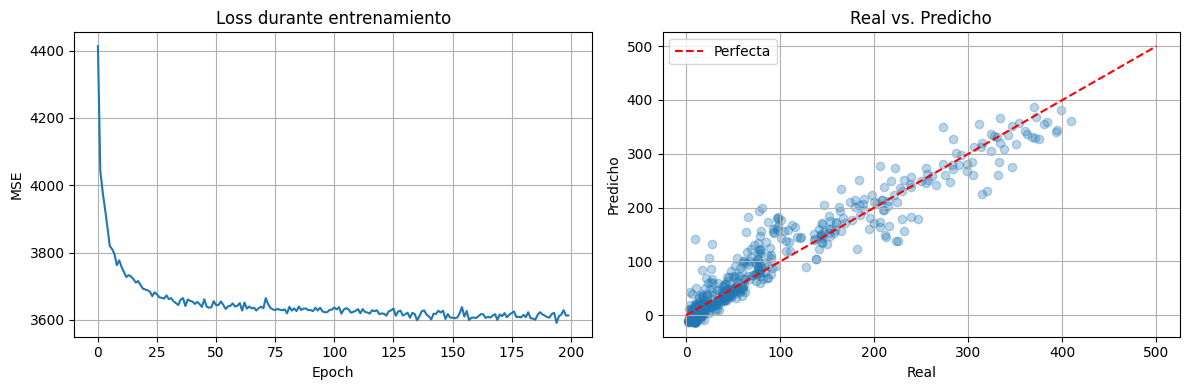

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(l)
plt.title("Loss durante entrenamiento")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test[:500], y_pred_test.cpu().numpy()[:500], alpha=0.3)
plt.plot([0, 500], [0, 500], 'r--', label='Perfecta')
plt.title("Real vs. Predicho"); plt.xlabel("Real"); plt.ylabel("Predicho")
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

**CLASIFICACION CON PYTORCH**

**Dataset:** Online News Popularity

**Importaciones necesarias**

**LABORATORIO 05: REGRESION LINEAL CON PYTORCH**

**Nombre**: Sebastian Gustavo Rojas Peralta

**Dataset:**

**Importaciones Necesarias**

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

True
Usando: cuda


**Carga y preparacion del dataset**

In [23]:
df = pd.read_csv('/content/drive/MyDrive/machine learning/datsets/OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()  #cn eso se quita espacios en los nombres

df = df.drop(columns=['url'])

# Usamos la mediana (1400) como umbral
df['popular'] = (df['shares'] >= 1400).astype(int)

# Todas las columnas menos shares y popular son nuestras entradas
columnas_x = [c for c in df.columns if c not in ['shares', 'popular']]
columna_y  = 'popular'

X = df[columnas_x].values.astype(float)
y = df[columna_y].values

print(f"Variables de entrada: {len(columnas_x)}")
print(f"Filas totales: {len(X)}")
print(f"Artículos populares: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Artículos no populares: {(1-y).sum()} ({(1-y.mean())*100:.1f}%)")

Variables de entrada: 59
Filas totales: 39644
Artículos populares: 21154 (53.4%)
Artículos no populares: 18490 (46.6%)


**Normalizacion de datos**

In [24]:
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_std[X_std == 0] = 1  # evitamos dividir por cero si alguna columna no varía

X = (X - X_mean) / X_std

**Split y tensores**

In [25]:
split = int(len(X) * 0.8)

X_train_t = torch.tensor(X[:split], dtype=torch.float32).to(device)
y_train_t = torch.tensor(y[:split], dtype=torch.float32).unsqueeze(1).to(device)
X_test    = X[split:]
y_test    = y[split:]

print(f"Entrenamiento: {len(X_train_t)} filas")
print(f"Prueba: {len(X_test)} filas")

Entrenamiento: 31715 filas
Prueba: 7929 filas


**Creacion del Dataloader**

In [26]:
dataloader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

print(f"Batches por epoch: {len(dataloader)}")

Batches por epoch: 496


**Definición del Modelo**

In [27]:
D_in, H, D_out = len(columnas_x), 64, 1

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
    torch.nn.Sigmoid()
).to(device)

# BCELoss = Binary Cross Entropy, la función de pérdida para clasificación binaria
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
#Entrenamiento
epochs   = 200
log_each = 10
l        = []

model.train()
for e in range(1, epochs + 1):

    _l = []
    for x_b, y_b in dataloader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        y_pred = model(x_b)           # forward
        loss   = criterion(y_pred, y_b)
        _l.append(loss.item())

        optimizer.zero_grad()         # limpiar gradientes
        loss.backward()               # backprop (autograd)
        optimizer.step()              # actualizar pesos

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs}  Loss {np.mean(l):.4f}")
        torch.save(model.state_dict(), f"./checkpoint_{e}.pt")

Epoch 10/200  Loss 0.6077
Epoch 20/200  Loss 0.5979
Epoch 30/200  Loss 0.5915
Epoch 40/200  Loss 0.5866
Epoch 50/200  Loss 0.5828
Epoch 60/200  Loss 0.5794
Epoch 70/200  Loss 0.5765
Epoch 80/200  Loss 0.5739
Epoch 90/200  Loss 0.5716
Epoch 100/200  Loss 0.5694
Epoch 110/200  Loss 0.5675
Epoch 120/200  Loss 0.5657
Epoch 130/200  Loss 0.5641
Epoch 140/200  Loss 0.5625
Epoch 150/200  Loss 0.5611
Epoch 160/200  Loss 0.5598
Epoch 170/200  Loss 0.5586
Epoch 180/200  Loss 0.5574
Epoch 190/200  Loss 0.5563
Epoch 200/200  Loss 0.5553


Para el entrenamiento se usó SGD, que es el optimizador visto en clases. Sin embargo, por sí solo aprendía demasiado lento, por lo que se le agregó momentum de 0.9, que básicamente le da un "empujón" extra en la dirección en que ya venía bajando el error, haciendo que converja más rápido y de forma más estable. También se probó una red más profunda con dos capas ocultas, pero esto causó overfitting — el modelo memorizó los datos de entrenamiento y al probarlo con datos nuevos rindió peor. Por eso se mantuvo la red simple con una sola capa oculta de 64 neuronas y 200 epochs, logrando un accuracy final de 63.27%.

**Evaluacion de Modelo**

In [28]:
model.eval()
with torch.no_grad():
    y_pred_test = model(torch.from_numpy(X_test).float().to(device))

# Convertimos probabilidades a clases: si prob >= 0.5 → popular (1), si no → 0
y_pred_clases = (y_pred_test.cpu().numpy() >= 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, y_pred_clases)
print(f"Accuracy en test: {accuracy*100:.2f}%")

Accuracy en test: 62.90%


**Gráficas**

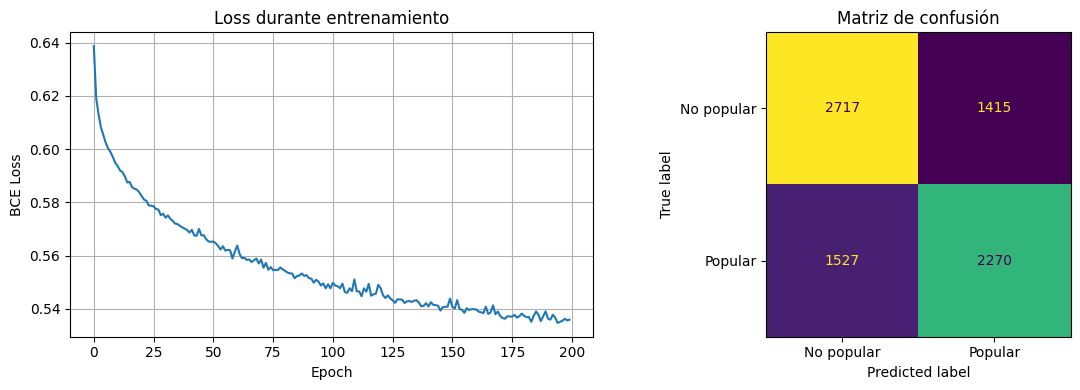

In [29]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(l)
plt.title("Loss durante entrenamiento")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss"); plt.grid(True)

plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred_clases)
disp = ConfusionMatrixDisplay(cm, display_labels=["No popular", "Popular"])
disp.plot(ax=plt.gca(), colorbar=False)
plt.title("Matriz de confusión")

plt.tight_layout()
plt.show()

**LREGRESION LINEAL CON PYTORCH**



**Dataset:**

**Importaciones Necesarias**

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

True
Usando: cuda


**Carga y preparacion del dataset**

In [31]:
df = pd.read_csv('/content/drive/MyDrive/machine learning/datsets/UNSW_NB15_training-set.csv')

# Eliminamos id y label (label es binario, nosotros usamos attack_cat que es multiclase)
df = df.drop(columns=['id', 'label'])

# Convertimos las columnas de texto a números con one-hot encoding
df = pd.get_dummies(df, columns=['proto', 'service', 'state'])

# La columna objetivo es attack_cat — la convertimos a números
# Normal=0, Generic=1, Exploits=2, etc.
le = LabelEncoder()
df['attack_cat'] = le.fit_transform(df['attack_cat'])

columnas_x = [c for c in df.columns if c != 'attack_cat']
columna_y  = 'attack_cat'

X = df[columnas_x].values.astype(float)
y = df[columna_y].values

print(f"Variables de entrada: {len(columnas_x)}")
print(f"Filas totales: {len(X)}")
print(f"Clases: {le.classes_}")
print(f"Distribución:")
for i, clase in enumerate(le.classes_):
    print(f"  {i} - {clase}: {(y==i).sum()} filas")

Variables de entrada: 190
Filas totales: 82332
Clases: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Distribución:
  0 - Analysis: 677 filas
  1 - Backdoor: 583 filas
  2 - DoS: 4089 filas
  3 - Exploits: 11132 filas
  4 - Fuzzers: 6062 filas
  5 - Generic: 18871 filas
  6 - Normal: 37000 filas
  7 - Reconnaissance: 3496 filas
  8 - Shellcode: 378 filas
  9 - Worms: 44 filas


**Nomralización de Datos**

In [32]:
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_std[X_std == 0] = 1

X = (X - X_mean) / X_std

**Split y tensores**

In [33]:
split = int(len(X) * 0.8)

# Convertimos y mandamos a GPU
X_train_t = torch.from_numpy(X[:split]).float().to(device)
y_train_t = torch.from_numpy(y[:split]).long().to(device)   # ← long para multiclase

X_test = X[split:]
y_test = y[split:]

print(f"Entrenamiento: {len(X_train_t)} filas")
print(f"Prueba: {len(X_test)} filas")

Entrenamiento: 65865 filas
Prueba: 16467 filas


**Creación del dataloader**

In [34]:
dataloader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

print(f"Batches por epoch: {len(dataloader)}")

Batches por epoch: 1030


**Definición del Modelo**


In [35]:
D_in  = len(columnas_x)
H     = 64
D_out = 10   # ← 10 clases posibles

model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out)
).to(device)


# CrossEntropyLoss = función de pérdida para multiclase
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
#Entrenamiento
epochs   = 200
log_each = 20
l        = []

model.train()
for e in range(1, epochs + 1):

    _l = []
    for x_b, y_b in dataloader:
        x_b = x_b.to(device)
        y_b = y_b.to(device)

        y_pred = model(x_b)           # forward
        loss   = criterion(y_pred, y_b)
        _l.append(loss.item())

        optimizer.zero_grad()         # limpiar gradientes
        loss.backward()               # backprop (autograd)
        optimizer.step()              # actualizar pesos

    l.append(np.mean(_l))
    if not e % log_each:
        print(f"Epoch {e}/{epochs}  Loss {np.mean(l):.4f}")
        torch.save(model.state_dict(), f"./checkpoint_{e}.pt")

Epoch 20/200  Loss 0.4707
Epoch 40/200  Loss 0.4415
Epoch 60/200  Loss 0.4256
Epoch 80/200  Loss 0.4150
Epoch 100/200  Loss 0.4074
Epoch 120/200  Loss 0.4015
Epoch 140/200  Loss 0.3968
Epoch 160/200  Loss 0.3928
Epoch 180/200  Loss 0.3894
Epoch 200/200  Loss 0.3864


**Evaluación del Modelo**

In [36]:
model.eval()
with torch.no_grad():
    y_pred_test = model(torch.from_numpy(X_test).float().to(device))

# En multiclase tomamos la clase con mayor probabilidad
y_pred_clases = torch.argmax(y_pred_test, dim=1).cpu().numpy()

accuracy = accuracy_score(y_test, y_pred_clases)
print(f"Accuracy en test: {accuracy*100:.2f}%")

Accuracy en test: 77.63%


**Gráficas**

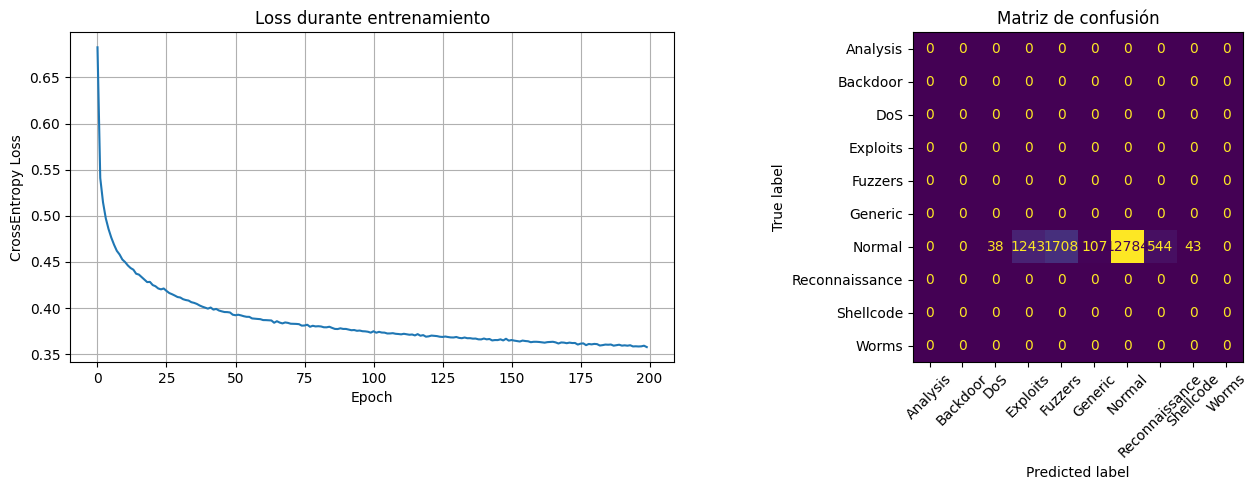

In [37]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(l)
plt.title("Loss durante entrenamiento")
plt.xlabel("Epoch"); plt.ylabel("CrossEntropy Loss"); plt.grid(True)

plt.subplot(1, 2, 2)
# Fix: Pass all possible labels to confusion_matrix to ensure a 10x10 matrix
cm = confusion_matrix(y_test, y_pred_clases, labels=np.arange(len(le.classes_)))
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=plt.gca(), colorbar=False, xticks_rotation=45)
plt.title("Matriz de confusión")

plt.tight_layout()
plt.show()